### This notebook is for doing an EDA of the American Community Survey data available from the US Census bureau. This data utlizes an API to pull information. I learned how to use their API here: https://www.census.gov/data/academy/courses/intro-to-the-census-bureau-data-api.html#1

Pulling in requests and pandas:

In [1]:
import requests

import pandas as pd

Pulling in and cleaning up the zip code list that I will use in the API url. This was sourced from Louisville Metro's Open Data portal: https://louisville-metro-opendata-lojic.hub.arcgis.com/datasets/LOJIC::jefferson-county-ky-zip-codes/explore?location=38.192334%2C-85.695891%2C10

In [2]:
ziplist_df = pd.read_csv('../data/Jefferson_County_KY_ZIP_Codes.csv')
ziplist_df.head()

,OBJECTID,ZIPCODE,SHAPEAREA,SHAPELEN
0,1,40203,8.608996e+07,76402.584655
1,2,40210,8.825244e+07,58504.651674
2,3,40059,3.342632e+08,102937.557822
3,4,40220,2.150630e+08,85234.904721
4,5,40041,3.513355e+06,8445.222310


In [3]:
ziplist_df = ziplist_df.drop('OBJECTID', axis=1)
ziplist_df = ziplist_df.drop('SHAPEAREA', axis=1)
ziplist_df = ziplist_df.drop('SHAPELEN', axis=1)

ziplist_df

,ZIPCODE
0,40203
1,40210
2,40059
3,40220
4,40041
5,40047
6,40242
7,40211
8,40215
9,40205


In [4]:
ziplist_df.dtypes

ZIPCODE    int64
dtype: object

In [5]:
ziplist_df['ZIPCODE'] = ziplist_df['ZIPCODE'].astype(str)
ziplist_df.dtypes

ZIPCODE    str
dtype: object

In [6]:
duplicate_counts = ziplist_df.apply(lambda x: x.duplicated(keep=False).sum())
print(duplicate_counts)

ZIPCODE    2
dtype: int64


In [7]:
ziplist_df[ziplist_df.duplicated(['ZIPCODE'], keep=False)]

,ZIPCODE
6,40242
18,40242


I have no need to keep two of the same zip code as I am not using the shape data, so I will drop the extra zip code.

In [8]:
cleaned_ziplist_df = ziplist_df.drop_duplicates()
cleaned_ziplist_df

,ZIPCODE
0,40203
1,40210
2,40059
3,40220
4,40041
5,40047
6,40242
7,40211
8,40215
9,40205


This next step prepares the zip codes for being added to the API's url. I am doing this to fully capture income information for Louisville Metro/Jefferson County.

In [9]:
zip_code_list = cleaned_ziplist_df['ZIPCODE'].tolist()

In [10]:
zip_codes = ','.join(zip_code_list)
zip_codes

'40203,40210,40059,40220,40041,40047,40242,40211,40215,40205,40218,40222,40223,40067,40177,40212,40214,40299,40245,40243,40025,40109,40241,40206,40219,40258,40213,40204,40208,40216,40118,40202,40217,40207,40225,40229,40023,40272,40209,40228,40291'

#### API for census.gov

The API url is below. If you want to get your own key, you can go to https://www.census.gov/data/developers/data-sets.html and click on "Request a Key" on the left side. It's free and comes to your email within a few minutes. Otherwise, you can reach out to me. Once you have the API key, fill it in under the *census_key* variable. That being said, you can run this project without obtaining an API key as long as you are under 500 requests for your IP address.

The year is a variable since I will be pulling information from 2021 to 2024. I am only looking for the median income levels, so I used the specific variable to just get that from the tables instead of all the other income information available.

In [11]:
census_key = ''

year = '2024'

zip_code_base_url = f"https://api.census.gov/data/{year}/acs/acs5/subject?get=NAME,S1901_C01_012E&for=zip%20code%20tabulation%20area:{zip_codes}&key={census_key}"

In [12]:
zip_response = requests.get(zip_code_base_url)

zip_response.status_code

200

In [13]:
data = zip_response.json()
data

[['NAME', 'S1901_C01_012E', 'zip code tabulation area'],
 ['ZCTA5 40023', '144635', '40023'],
 ['ZCTA5 40025', '250001', '40025'],
 ['ZCTA5 40041', '153214', '40041'],
 ['ZCTA5 40047', '99124', '40047'],
 ['ZCTA5 40059', '152727', '40059'],
 ['ZCTA5 40067', '97684', '40067'],
 ['ZCTA5 40109', '75495', '40109'],
 ['ZCTA5 40118', '59316', '40118'],
 ['ZCTA5 40177', '50577', '40177'],
 ['ZCTA5 40202', '35584', '40202'],
 ['ZCTA5 40203', '30794', '40203'],
 ['ZCTA5 40204', '71116', '40204'],
 ['ZCTA5 40205', '99966', '40205'],
 ['ZCTA5 40206', '75798', '40206'],
 ['ZCTA5 40207', '101898', '40207'],
 ['ZCTA5 40208', '39560', '40208'],
 ['ZCTA5 40209', '-666666666', '40209'],
 ['ZCTA5 40210', '35347', '40210'],
 ['ZCTA5 40211', '31749', '40211'],
 ['ZCTA5 40212', '35753', '40212'],
 ['ZCTA5 40213', '55897', '40213'],
 ['ZCTA5 40214', '54931', '40214'],
 ['ZCTA5 40215', '43725', '40215'],
 ['ZCTA5 40216', '56441', '40216'],
 ['ZCTA5 40217', '69114', '40217'],
 ['ZCTA5 40218', '58811', '40218'

In [14]:

def get_median_income_data(year, zip_code_sing):
    zip_response = requests.get(f"https://api.census.gov/data/{year}/acs/acs5/subject?get=NAME,S1901_C01_012E&for=zip%20code%20tabulation%20area:{zip_code_sing}&key={census_key}")
    zip_response.status_code
    if zip_response.status_code == 200:
        median_income_data = zip_response.json()
        return median_income_data
    elif zip_response.status_code == 204:
        print(f"No data for {zip_code_sing}")

    else: print(f"Error fetching data from census.gov: {zip_response.status_code}")

In [15]:
get_median_income_data(2024, 40206)

[['NAME', 'S1901_C01_012E', 'zip code tabulation area'],
 ['ZCTA5 40206', '75798', '40206']]

Now that I've got a working function to pull information, I am going to write another one to pull all information I need for median income across zip codes and years. I will add a column for year so that I know which year each median income and zip code is coming from.

In [16]:
from itertools import product
years = range(2021, 2025)

def get_median_income_data_all_years(years, zip_code_list):
    median_income_data_all_years = []
    #product is a more efficent way of iterating through years and zip_code_list without nesting for loops
    for year, zip_code_sing in product(years, zip_code_list):
        try:
            median_income = get_median_income_data(year, zip_code_sing)
            if median_income and len(median_income) > 0 and len(median_income[0]) >= 2:
                    #checks to see if the median income data is a tuple or list
                    row = median_income[1]
                    median_income_data_all_years.append({
                        'year': year,
                        'zip_code': row[2] if len(row) >2 else zip_code_sing,
                        'median_income_val': row[1]
                    })
            else:
                  print(f"No data found for {year} and {zip_code_sing}.")
        except Exception as e:
              print(f"Error retrieving {year} and {zip_code_sing}: {e}.")
    return median_income_data_all_years

I stumbled upon itertools from google-searching my errors, and it has made the function more efficient! As a side note, it has been taking about two minutes for the function to retrieve all the data across years and zip codes, so if it goes much longer than that, you may want to restart your kernel.

In [17]:
median_income_prepped = get_median_income_data_all_years(years, zip_code_list)
median_income_df = pd.DataFrame(median_income_prepped)
median_income_df.head()

No data for 40225
No data found for 2021 and 40225.
No data for 40225
No data found for 2022 and 40225.
No data for 40225
No data found for 2023 and 40225.
No data for 40225
No data found for 2024 and 40225.


,year,zip_code,median_income_val
0,2021,40203,26968
1,2021,40210,29733
2,2021,40059,161079
3,2021,40220,68598
4,2021,40041,-666666666


#### EDA on Census Data

Now that I have the census data in a dataframe, it is time to do EDA on the census data.

In [18]:
median_income_df.dtypes

year                 int64
zip_code               str
median_income_val      str
dtype: object

In [19]:
median_income_df['year'] = pd.to_datetime(median_income_df['year'], format='%Y')
median_income_df['zip_code'] = median_income_df['zip_code'].astype(object)
median_income_df['median_income_val'] = pd.to_numeric(median_income_df['median_income_val'])

In [20]:
median_income_df.dtypes

year                 datetime64[us]
zip_code                     object
median_income_val             int64
dtype: object

In [21]:
median_income_df.isnull().sum()

year                 0
zip_code             0
median_income_val    0
dtype: int64

In [22]:
median_income_df


,year,zip_code,median_income_val
0,2021-01-01,40203,26968
1,2021-01-01,40210,29733
2,2021-01-01,40059,161079
3,2021-01-01,40220,68598
4,2021-01-01,40041,-666666666
...,...,...,...
155,2024-01-01,40023,144635
156,2024-01-01,40272,69940
157,2024-01-01,40209,-666666666
158,2024-01-01,40228,79404


In [23]:
median_income_df['median_income_val'].agg(['min', 'max'])

min   -666666666
max       250001
Name: median_income_val, dtype: int64

It looks like there are some income values set to a very low negative number. According to https://www.census.gov/data/developers/data-sets/acs-1year/notes-on-acs-estimate-and-annotation-values.html, this indicates that there was insufficient data observations to make a decision. Since I am using the 5-year set, it seems that the margin of error was greater than the median itself. These values should be set to 'unknown' or 'null'. It would be worth seeing if this is for the same zip code across years or different zip codes for different years.

In [24]:
filtered_66_median_income_df = median_income_df[median_income_df['median_income_val'] == -666666666]
filtered_66_median_income_df

,year,zip_code,median_income_val
4,2021-01-01,40041,-666666666
44,2022-01-01,40041,-666666666
84,2023-01-01,40041,-666666666
157,2024-01-01,40209,-666666666


In [25]:
filtered_55_median_income_df = median_income_df[median_income_df['median_income_val'] == -555555555]
filtered_55_median_income_df

,year,zip_code,median_income_val


In [26]:
filtered_33_median_income_df = median_income_df[median_income_df['median_income_val'] == -333333333]
filtered_33_median_income_df

,year,zip_code,median_income_val


In [27]:
filtered_22_median_income_df = median_income_df[median_income_df['median_income_val'] == -222222222]
filtered_22_median_income_df

,year,zip_code,median_income_val


In [28]:
filtered_0_median_income_df = median_income_df[median_income_df['median_income_val'] == 0]
filtered_0_median_income_df

,year,zip_code,median_income_val


This covers all the variations on issues there could be with the data. It looks like there are 3 inconclusive years for 40041, and one inconclusive year for 40209.

40041 is a P.O. Box only postal code assigned to the Masonic Homes campus in the 40207 zip code area. I will go ahead and drop 40041 results from the dataframe and assume 40207 if 40041 is reported in the LMAS intake data.

Since 40209 is an actual area of the city that includes the fairgrounds and the airport, the population isn't very big. I will keep the results but make it zero as there are no 0 values currently.

In [29]:
median_income_df = median_income_df[median_income_df.zip_code != '40041']
median_income_df

,year,zip_code,median_income_val
0,2021-01-01,40203,26968
1,2021-01-01,40210,29733
2,2021-01-01,40059,161079
3,2021-01-01,40220,68598
5,2021-01-01,40047,82621
...,...,...,...
155,2024-01-01,40023,144635
156,2024-01-01,40272,69940
157,2024-01-01,40209,-666666666
158,2024-01-01,40228,79404


In [30]:
median_income_df_filtered_zip = median_income_df[median_income_df['zip_code'] == '40041']
median_income_df_filtered_zip

,year,zip_code,median_income_val


In [31]:
median_income_df.loc[median_income_df['median_income_val'] < 0, 'median_income_val'] = 0
median_income_df

,year,zip_code,median_income_val
0,2021-01-01,40203,26968
1,2021-01-01,40210,29733
2,2021-01-01,40059,161079
3,2021-01-01,40220,68598
5,2021-01-01,40047,82621
...,...,...,...
155,2024-01-01,40023,144635
156,2024-01-01,40272,69940
157,2024-01-01,40209,0
158,2024-01-01,40228,79404


In [32]:
from pathlib import Path

export_path = Path("../Data/median_income_data.csv")
median_income_df.to_csv(export_path, index=False)


#### Visualization

For visualization, I am going to use GeoPandas. My original zip code list file has shape data in it, so I should be able to use this.

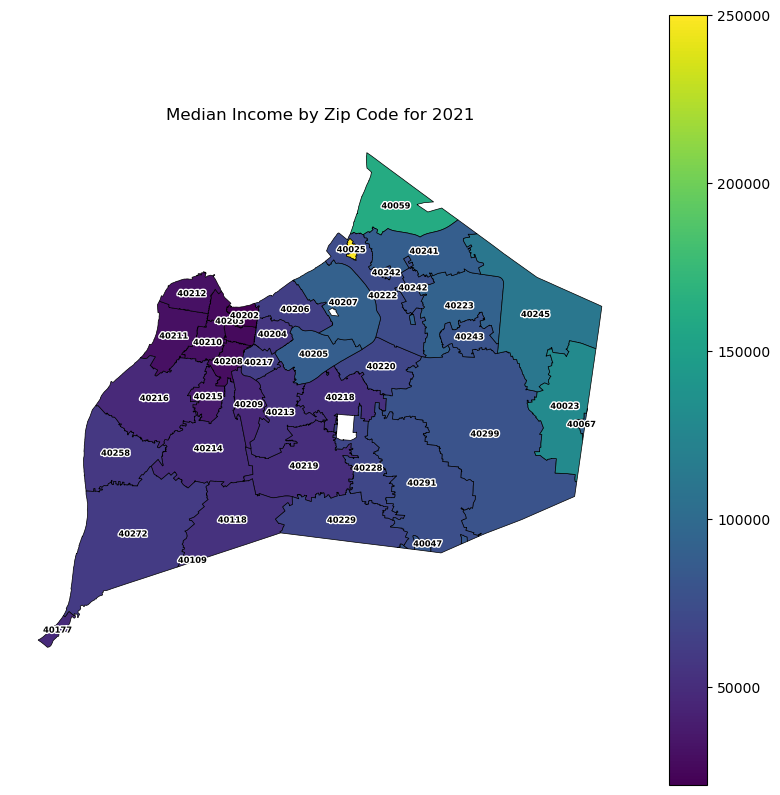

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

year_2021_filtered_median_income_df = median_income_df[median_income_df['year'] == '2021-01-01']

zip_shape_gdf = gpd.read_file('../data/shp_Jefferson_County_KY_ZIP_Codes.shp')

year_2021_filtered_median_income_df['zip_code'] = year_2021_filtered_median_income_df['zip_code'].astype(str).str.zfill(5)
merged_zip = zip_shape_gdf.merge(year_2021_filtered_median_income_df, left_on='ZIPCODE', right_on='zip_code')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_zip.plot(edgecolor='black', column='median_income_val', ax=ax, legend=True, cmap='viridis', linewidth=0.5)
for x, y, label in zip(merged_zip.geometry.centroid.x, merged_zip.geometry.centroid.y, merged_zip.ZIPCODE):
    ax.text(x, y, label, fontsize=6, fontweight='bold', color='black', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

plt.title('Median Income by Zip Code for 2021')
ax.set_axis_off()
plt.show()

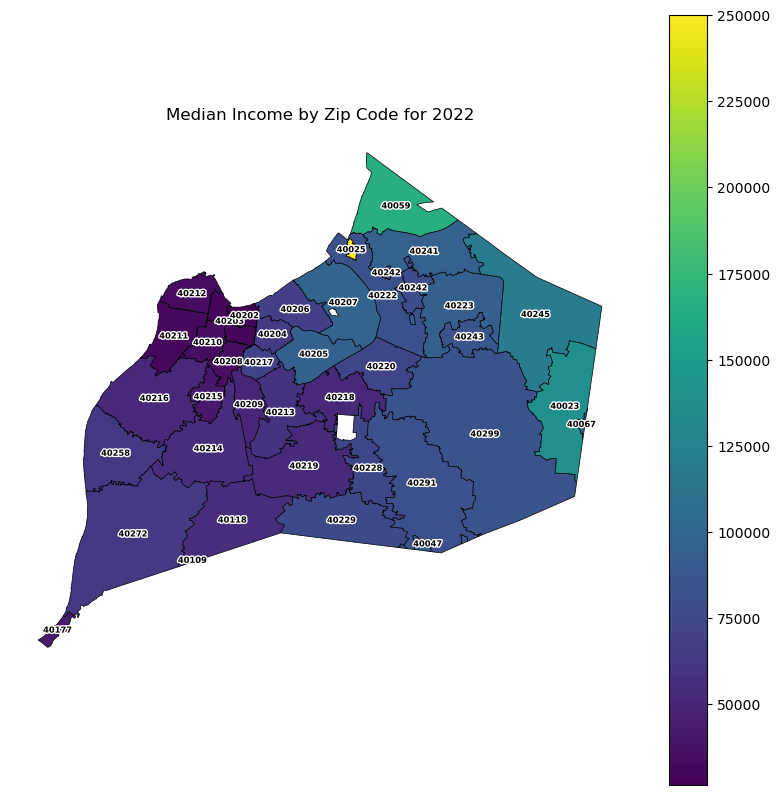

In [34]:
year_2022_filtered_median_income_df = median_income_df[median_income_df['year'] == '2022-01-01']

zip_shape_gdf = gpd.read_file('../data/shp_Jefferson_County_KY_ZIP_Codes.shp')

year_2022_filtered_median_income_df['zip_code'] = year_2022_filtered_median_income_df['zip_code'].astype(str).str.zfill(5)
merged_zip = zip_shape_gdf.merge(year_2022_filtered_median_income_df, left_on='ZIPCODE', right_on='zip_code')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_zip.plot(edgecolor='black', column='median_income_val', ax=ax, legend=True, cmap='viridis', linewidth=0.5)
for x, y, label in zip(merged_zip.geometry.centroid.x, merged_zip.geometry.centroid.y, merged_zip.ZIPCODE):
    ax.text(x, y, label, fontsize=6, fontweight='bold', color='black', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

plt.title('Median Income by Zip Code for 2022')
ax.set_axis_off()
plt.show()

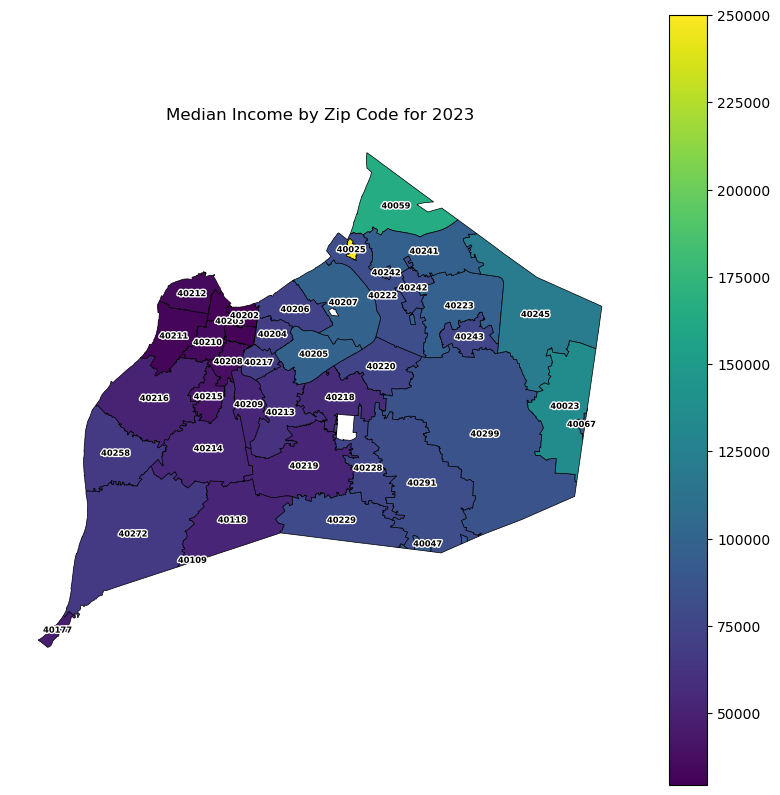

In [35]:
year_2023_filtered_median_income_df = median_income_df[median_income_df['year'] == '2023-01-01']

zip_shape_gdf = gpd.read_file('../data/shp_Jefferson_County_KY_ZIP_Codes.shp')

year_2023_filtered_median_income_df['zip_code'] = year_2023_filtered_median_income_df['zip_code'].astype(str).str.zfill(5)
merged_zip = zip_shape_gdf.merge(year_2023_filtered_median_income_df, left_on='ZIPCODE', right_on='zip_code')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_zip.plot(edgecolor='black', column='median_income_val', ax=ax, legend=True, cmap='viridis', linewidth=0.5)
for x, y, label in zip(merged_zip.geometry.centroid.x, merged_zip.geometry.centroid.y, merged_zip.ZIPCODE):
    ax.text(x, y, label, fontsize=6, fontweight='bold', color='black', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

plt.title('Median Income by Zip Code for 2023')
ax.set_axis_off()
plt.show()

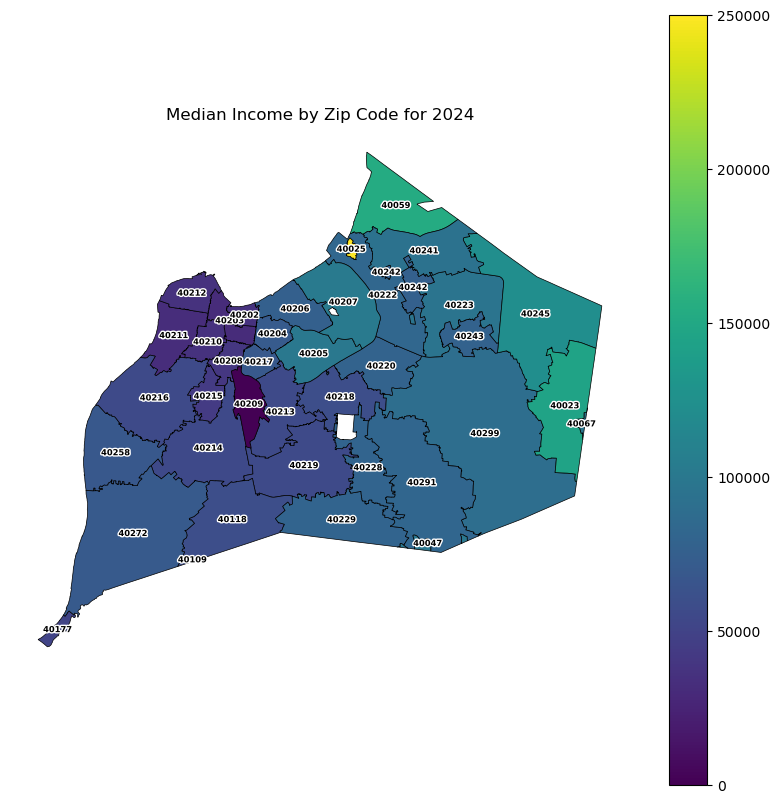

In [36]:
year_2024_filtered_median_income_df = median_income_df[median_income_df['year'] == '2024-01-01']

zip_shape_gdf = gpd.read_file('../data/shp_Jefferson_County_KY_ZIP_Codes.shp')

year_2024_filtered_median_income_df['zip_code'] = year_2024_filtered_median_income_df['zip_code'].astype(str).str.zfill(5)
merged_zip = zip_shape_gdf.merge(year_2024_filtered_median_income_df, left_on='ZIPCODE', right_on='zip_code')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_zip.plot(edgecolor='black', column='median_income_val', ax=ax, legend=True, cmap='viridis', linewidth=0.5)
for x, y, label in zip(merged_zip.geometry.centroid.x, merged_zip.geometry.centroid.y, merged_zip.ZIPCODE):
    ax.text(x, y, label, fontsize=6, fontweight='bold', color='black', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

plt.title('Median Income by Zip Code for 2024')
ax.set_axis_off()
plt.show()

The two white gaps in the maps are consistent with the locations of 40225, which had no data retrieved, and 40041, which I decided to drop due to it being a small area in 40207.

I think I feel comfortable with this data and will start on the process of integrating it with LMAS intake data.